# MCNN training and testing on UCF-QNRF dataset (Crowd Counting)

In [2]:

import os
import cv2
import numpy as np
import scipy.io
from PIL import Image
import tensorflow as tf
from tensorflow import keras 
from keras import layers
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt

In [4]:
def load_annotations(mat_path):
    mat = scipy.io.loadmat(mat_path)
    return mat["annPoints"]

# === Generate Gaussian density map ===
def generate_density_map(image_shape, points, sigma=4):
    h, w = image_shape
    density = np.zeros((h, w), dtype=np.float32)
    for point in points:
        x, y = int(min(w - 1, point[0])), int(min(h - 1, point[1]))
        density[y, x] += 1
    density = cv2.GaussianBlur(density, (0, 0), sigma)
    if density.sum() > 0:
        density *= len(points) / density.sum() 
    return density


In [5]:
# === Dataset generator ===
class UCFQNRFDataset(Sequence):
    def __init__(self, img_dir, img_list, img_size=(256, 256), batch_size=4):
        self.img_dir = img_dir
        self.img_paths = img_list
        self.img_size = img_size
        self.batch_size = batch_size

    def __len__(self):
        return len(self.img_paths) // self.batch_size

    def __getitem__(self, idx):
        batch_paths = self.img_paths[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_images, batch_density = [], []

        for fname in batch_paths:
            img_path = os.path.join(self.img_dir, fname)
            mat_path = img_path.replace(".jpg", "_ann.mat").replace("\\", "/")
            if not os.path.exists(mat_path):
                print(f"Annotation file {mat_path} does not exist. Skipping {fname}.")
                continue

            # Load and resize image
            img_raw = Image.open(img_path).convert("RGB")
            original_size = img_raw.size
            img = img_raw.resize(self.img_size)
            img = np.array(img) / 255.0

            # Scale points and generate density map
            points = load_annotations(mat_path)
            scale_x = self.img_size[0] / original_size[0]
            scale_y = self.img_size[1] / original_size[1]
            points_scaled = [[x * scale_x, y * scale_y] for x, y in points]
            density = generate_density_map(self.img_size, points_scaled)

            batch_images.append(img)
            batch_density.append(np.expand_dims(density, axis=-1))

        return np.array(batch_images), np.array(batch_density)


In [6]:
# === MCNN model ===
def build_mcnn(input_shape):
    inputs = keras.Input(shape=input_shape)

    # Column 1 (large receptive field)
    c1 = layers.Conv2D(16, 9, padding="same", activation="relu")(inputs)
    c1 = layers.MaxPool2D()(c1)
    c1 = layers.Conv2D(32, 7, padding="same", activation="relu")(c1)
    c1 = layers.MaxPool2D()(c1)
    c1 = layers.Conv2D(16, 7, padding="same", activation="relu")(c1)

    # Column 2 (medium receptive field)
    c2 = layers.Conv2D(20, 7, padding="same", activation="relu")(inputs)
    c2 = layers.MaxPool2D()(c2)
    c2 = layers.Conv2D(40, 5, padding="same", activation="relu")(c2)
    c2 = layers.MaxPool2D()(c2)
    c2 = layers.Conv2D(20, 5, padding="same", activation="relu")(c2)

    # Column 3 (small receptive field)
    c3 = layers.Conv2D(24, 5, padding="same", activation="relu")(inputs)
    c3 = layers.MaxPool2D()(c3)
    c3 = layers.Conv2D(48, 3, padding="same", activation="relu")(c3)
    c3 = layers.MaxPool2D()(c3)
    c3 = layers.Conv2D(24, 3, padding="same", activation="relu")(c3)

    # Merge columns
    merged = layers.Concatenate()([c1, c2, c3])
    output = layers.Conv2D(1, 1, padding="same", activation="relu")(merged)
    output = layers.UpSampling2D(size=(4, 4))(output)  # Upsample to match input size

    return keras.Model(inputs, output)

In [7]:
img_dir = "UCF_GNRF/Train/"  
all_imgs = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])

train_imgs = all_imgs[:1200]
test_imgs = all_imgs[1200:]

input_shape = (256, 256, 3)
batch_size = 4

train_gen = UCFQNRFDataset(img_dir, train_imgs, img_size=input_shape[:2], batch_size=batch_size)
test_gen = UCFQNRFDataset(img_dir, test_imgs, img_size=input_shape[:2], batch_size=batch_size)

In [9]:
model = build_mcnn(input_shape)
model.compile(optimizer=keras.optimizers.Adam(1e-4), loss='mse')
model.fit(train_gen, epochs=10)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 248s 817ms/step - loss: 0.0022
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 270s 901ms/step - loss: 0.0021
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 286s 954ms/step - loss: 0.0014
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 297s 984ms/step - loss: 0.0017
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 287s 953ms/step - loss: 0.0016
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 279s 929ms/step - loss: 0.0014
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 264s 878ms/step - loss: 0.0014
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 266s 886ms/step - loss: 0.0018
Epoch 9/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 290s 966ms/step - loss: 0.0023
Epoch 10/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 289s 964ms/step - loss: 0.0017


In [10]:
def evaluate_counting(model, dataset, n_samples=10):
    abs_errors = []
    for i in range(min(n_samples, len(dataset))):
        imgs, dens = dataset[i]
        preds = model.predict(imgs)
        for gt, pred in zip(dens, preds):
            true_count = np.sum(gt)
            pred_count = np.sum(pred)
            abs_errors.append(abs(true_count - pred_count))
    mae = np.mean(abs_errors)
    print(f"Mean Absolute Error (Count): {mae:.2f}")

print("\nEvaluation on Test Set:")
evaluate_counting(model, test_gen, n_samples=10)


Evaluation on Test Set:
Mean Absolute Error (Count): nan


c:\Users\Md Mominur Rahman\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Md Mominur Rahman\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


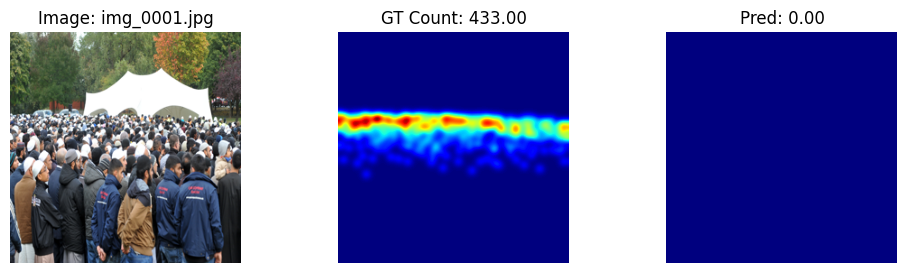

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


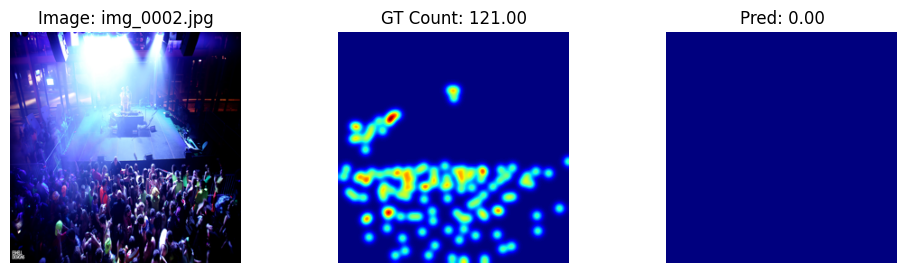

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


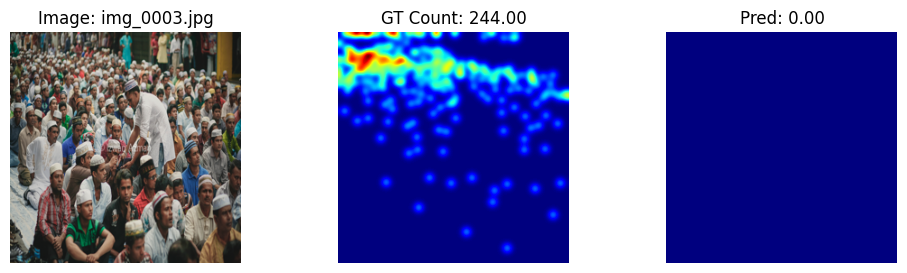

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


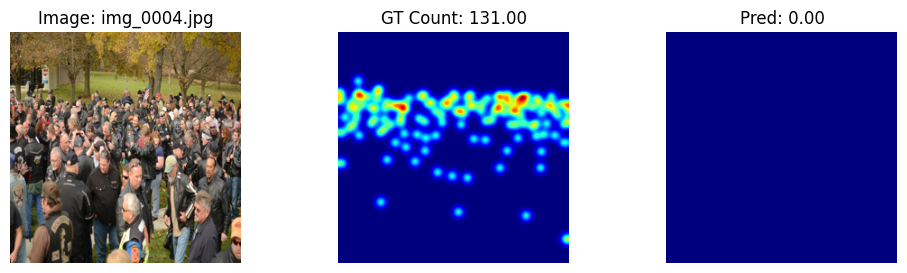

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


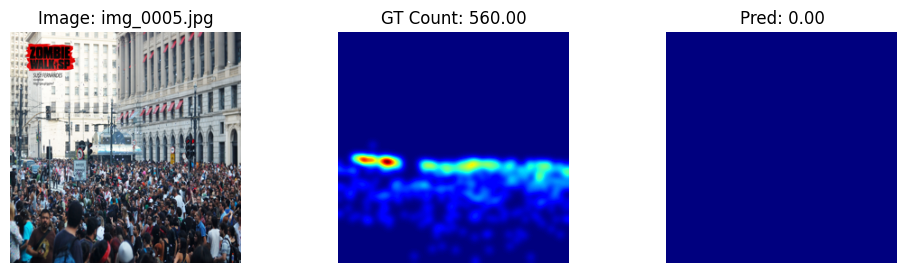

In [14]:
rowwise_gen = UCFQNRFDataset(img_dir, all_imgs, img_size=input_shape[:2], batch_size=1)

for i in range(5):
    img, density = rowwise_gen[i]
    img = img[0]
    density = density[0]
    pred_density = model.predict(np.expand_dims(img, axis=0))[0]

    plt.figure(figsize=(12, 3))
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"Image: {all_imgs[i]}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(density.squeeze(), cmap='jet')
    plt.title(f"GT Count: {np.sum(density):.2f}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_density.squeeze(), cmap='jet')
    plt.title(f"Pred: {np.sum(pred_density):.2f}")
    plt.axis("off")

    plt.show()